# 실습 2 · 파트 1 — 내 카메라 캘리브레이션

**내 폰을 캘리브레이션해 K와 σ를 얻는다**

| 노트북 | 내용 |
|---|---|
| **파트 1** (이 파일) | **내 카메라 캘리브레이션** — 촬영 규칙 · 보드 촬영 · K와 σ 확인 |
| 파트 2 | 매칭 `빈칸 ①` · 호모그래피 DLT `빈칸 ②` · RANSAC · 워핑 · 블렌딩 `빈칸 ③` → 내 파노라마 · 모듈화 |
| 파트 3 | 시간을 잇는 호모그래피 — "Dear Photograph" (클릭 대응 → 내 DLT) |

세 노트북은 **각각 독립적으로 실행**됩니다. 다만 이 노트북의 산출물 `out/my_params.json` 이 있으면
파트 2가 **내 K로 왜곡 보정까지** 적용합니다 (없으면 보정 없이 진행).

**폰 촬영이 여의치 않다면** — `my_calib/` 를 비워 두면 캘리브레이션을 건너뛰고,
파트 2는 대체 데이터(`data/hyu_*.jpeg`)로 진행됩니다.

In [1]:
# ── 셀 1 · 환경 준비 ────────────────────────────────────────────
import cv2, json, math, time, os, glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageOps

import matplotlib.font_manager as fm
for cand in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
             'Noto Sans CJK KR', 'Noto Sans CJK JP', 'Noto Sans KR']:
    if any(cand == f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = cand; break
plt.rcParams['axes.unicode_minus'] = False

# iPhone 사진은 확장자가 .jpg/.jpeg여도 내용이 HEIC인 경우가 많습니다 (전송 시 흔함)
try:
    import pillow_heif; pillow_heif.register_heif_opener()
except ImportError:
    print('⚠ pillow-heif 미설치 — HEIC 사진은 열리지 않습니다(UnidentifiedImageError).')
    print('  터미널에서  pip install pillow-heif  실행 후 커널 재시작하세요.')

BASE = Path('.'); OUT = BASE / 'out'; OUT.mkdir(exist_ok=True)
CALIB_DIR = BASE / 'my_calib'    # ← 내 폰으로 찍은 보드 사진 10~12장

def load_image(path, max_side=None):
    # EXIF 회전을 반영해 로드 (폰 사진 필수) → BGR, 필요 시 축소
    im = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    img = cv2.cvtColor(np.array(im), cv2.COLOR_RGB2BGR)
    if max_side and max(img.shape[:2]) > max_side:
        s = max_side / max(img.shape[:2])
        img = cv2.resize(img, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    return img

def show(img, title='', figsize=(9, 5.4)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title(title); plt.axis('off'); plt.show()

IMG_EXT = ('.jpg', '.jpeg', '.png', '.heic', '.heif')

def list_images(folder):
    # 확장자 대소문자 무관 · HEIC 포함 · 맥의 '._' 숨김 파일 제외
    if not folder.exists():
        return []
    return sorted(p for p in folder.iterdir()
                  if p.suffix.lower() in IMG_EXT and not p.name.startswith('.'))

print('OpenCV', cv2.__version__)
print('보드 사진:', len(list_images(CALIB_DIR)), '장 /', CALIB_DIR)

OpenCV 5.0.0
보드 사진: 130 장 / my_calib


---
## Part 1 · 내 카메라 캘리브레이션

어제 배운 촬영 프로토콜을 **본인 폰에 실전 적용**합니다. 스마트폰은 오토포커스·자동 렌즈 전환 때문에
K가 흔들릴 수 있으므로, 아래 규칙으로 "고정 카메라"처럼 만듭니다.

> **폰 촬영 규칙 (캘리브·파노라마 공통)**
> 1. **기본(1×) 렌즈 고정** — 0.5×/망원 전환 금지, 핀치 줌 금지 (디지털 줌은 K를 바꿈)
> 2. **AF/AE 잠금** — iPhone: 화면 길게 눌러 `AE/AF 잠금` · Android: 프로 모드 or 터치 잠금
> 3. HDR·야간 모드 **끄기** (여러 장 합성은 기하를 흔듦)
> 4. **가로 방향 고정** — 세로/가로를 섞으면 해상도 축이 뒤집힘
> 5. 보드 촬영: 어제의 권장 프로토콜 — **거리 2~3단계 × 기울기 4방향 × 위치 3×3존**, 10~12장
> 6. 전송: AirDrop / 드라이브 / USB → `my_calib/` 폴더에 저장
>
> 오토포커스의 미세한 초점거리 변화(focus breathing)는 보통 1% 미만 — 오늘 목적엔 충분히 안정적입니다.

보드는 **ChArUco 8×7 (DICT_5X5)** — 어제 실습 1의 AVM 리그와 같은 보드이고, 오늘은
**화면에 띄웁니다**: `board_screen.html`을 노트북/태블릿에서 열고 전체화면(F) → 그 화면을 폰으로 촬영.


> **화면 보드 체크리스트** — 밝기 최대·자동 밝기 끄기 / 화면에 조명·폰이 비치지 않는 각도(조명 등지기)
> / 커브드 모니터 금지 / 줄무늬(플리커)가 찍히면 밝기 한 단계 조정.
> 반사가 심한 환경이면 백업: `board/` 의 **A4 인쇄 PDF**.

[IMG_3365.jpeg] 코너 42/42 | 블러 지표 586 (참고: 수백 이상 무난) | 포화 화소 1.50%
판정: ✅ 통과 — 같은 요령으로 10~12장 채우세요 (거리·기울기·위치 다양하게!)


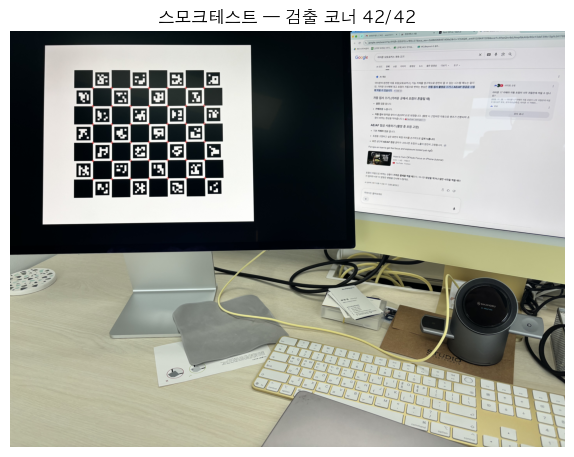

In [2]:
# ── 셀 2a · 촬영 스모크테스트 — 첫 1장부터 판정 ─────────────────
ARUCO = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_1000)
BOARD = cv2.aruco.CharucoBoard((8, 7), 0.04, 0.03, ARUCO)   # 실습 1과 동일 규격(비율 0.75, 스케일 무관)
CDET  = cv2.aruco.CharucoDetector(BOARD)
OBJ_B = BOARD.getChessboardCorners()                        # (42, 3)

def detect_charuco(gray, detect_side=1500, min_corners=15):
    # 큰 사진은 축소해 빠르게 검출 → 원해상도에서 cornerSubPix로 정밀 정제
    s = min(1.0, detect_side / max(gray.shape))
    g = cv2.resize(gray, None, fx=s, fy=s) if s < 1.0 else gray
    ch_c, ch_ids, _, _ = CDET.detectBoard(g)
    if ch_ids is None or len(ch_ids) < min_corners:
        return None, None
    c = (ch_c.reshape(-1, 1, 2) / s).astype(np.float32)
    crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 1e-3)
    c = cv2.cornerSubPix(gray, c, (11, 11), (-1, -1), crit)
    return c.reshape(-1, 2), ch_ids.ravel().astype(int)

smoke_files = sorted(list_images(CALIB_DIR), key=os.path.getmtime)
if not smoke_files:
    print('아직 사진이 없습니다 — board_screen.html 전체화면 → 규칙대로 1장 찍어 my_calib/에 넣고 재실행')
else:
    f = smoke_files[-1]                                  # 가장 최근 사진 1장 판정
    img = load_image(f); g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    c, ids = detect_charuco(g, min_corners=4)
    n = 0 if ids is None else len(ids)
    blur = cv2.Laplacian(cv2.resize(g, None, fx=0.5, fy=0.5), cv2.CV_64F).var()
    sat = (g > 250).mean() * 100
    print(f'[{f.name}] 코너 {n}/42 | 블러 지표 {blur:.0f} (참고: 수백 이상 무난) | 포화 화소 {sat:.2f}%')
    if n >= 25:   print('판정: ✅ 통과 — 같은 요령으로 10~12장 채우세요 (거리·기울기·위치 다양하게!)')
    elif n >= 15: print('판정: △ 사용 가능 — 반사·각도를 조금 조정하면 더 좋아집니다')
    else:
        print('판정: ❌ 재촬영 권장 —',
              '포화↑: 화면 반사(각도·조명 등지기)' if sat > 1.0 else
              ('블러: 폰 고정·화면 탭 초점' if blur < 150 else '보드가 작거나 잘림: 더 가까이/중앙에'))
    vis = img.copy()
    if n:
        for (x, y) in c.astype(int):
            cv2.circle(vis, (x, y), 9, (0, 0, 255), 2)
    show(vis, f'스모크테스트 — 검출 코너 {n}/42', (9, 5.4))

In [3]:
# ── 셀 2b · 내 폰 캘리브레이션 (ChArUco) ────────────────────────
def calibrate_my_phone(folder, min_imgs=8):
    files = list_images(folder)
    if len(files) < min_imgs:
        return None
    ops, ips, ncor, used, size = [], [], [], [], None
    for f in files:
        img = load_image(f); g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        size = g.shape[::-1]
        c, ids = detect_charuco(g)
        if c is None:
            print('  검출 부족(제외):', f.name); continue
        ops.append(OBJ_B[ids].reshape(-1, 1, 3).astype(np.float32))
        ips.append(c.reshape(-1, 1, 2).astype(np.float32))
        ncor.append(len(ids)); used.append(f.name)
    assert len(ops) >= min_imgs, f'검출 성공 {len(ops)}장 < {min_imgs}장 — 추가 촬영 필요'
    rms, K, dist, rv, tv, stdI, stdE, pve = cv2.calibrateCameraExtended(
        ops, ips, size, None, None)
    return dict(board='ChArUco 8x7 (DICT_5X5)', n=len(ops), size=size, rms=float(rms),
                corners_med=int(np.median(ncor)),
                K=K, dist=dist.ravel(), sigma_fx=float(stdI.ravel()[0]),
                sigma_k=[float(s) for s in stdI.ravel()[[4, 5, 8]]], files=used)

MY = calibrate_my_phone(CALIB_DIR)
if MY:
    fx = MY['K'][0, 0]
    print(f"{MY['board']} · {MY['n']}장 (코너/장 중앙값 {MY['corners_med']}) · 해상도 {MY['size']}")
    print(f"RMS {MY['rms']:.3f} px | fx = {fx:.1f} ± {MY['sigma_fx']:.2f} px "
          f"(상대 {MY['sigma_fx']/fx*100:.2f}%)")
    print(f"dist(k1,k2,p1,p2,k3) = {np.round(MY['dist'], 4)}")
    print('품질 체크:', 'RMS<1 ✅' if MY['rms'] < 1 else 'RMS≥1 ⚠ (흔들림·반사 프레임 제거 고려)',
          '| σ(fx)/fx<1% ✅' if MY['sigma_fx']/fx < 0.01 else '| σ(fx)/fx≥1% ⚠ (자세·거리 다양성 부족?)')
    json.dump({k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in MY.items()},
              open(OUT / 'my_params.json', 'w'), indent=2)
    print('저장 → out/my_params.json')
else:
    print('⚠ my_calib/ 사진이 부족합니다 — 캘리브레이션 없이(왜곡 보정 생략) 진행합니다.')

  검출 부족(제외): IMG_3429.jpeg
  검출 부족(제외): IMG_3430.jpeg
  검출 부족(제외): IMG_3431.jpeg
ChArUco 8x7 (DICT_5X5) · 127장 (코너/장 중앙값 42) · 해상도 (5712, 4284)
RMS 1.188 px | fx = 4388.0 ± 3.21 px (상대 0.07%)
dist(k1,k2,p1,p2,k3) = [ 0.0603 -0.1763 -0.0004 -0.004   0.236 ]
품질 체크: RMS≥1 ⚠ (흔들림·반사 프레임 제거 고려) | σ(fx)/fx<1% ✅
저장 → out/my_params.json


---
## 파트 1 마무리

- **내 폰도 캘리브레이션 대상** — 규칙(1× 고정·AF/AE 락)만 지키면 fx±σ까지 얻는다
- 산출물 `out/my_params.json` — 제출물이자, **파트 2의 첫 부품**(왜곡 보정)입니다
- 목표치: RMS < 1 px, σ(fx)/fx < 1%. 미달이면 흔들림·반사 프레임을 빼고 자세 다양성을 늘려 재촬영

다음 → **파트 2 노트북** (`lab2_part2_panorama.ipynb`) — 오늘의 빈칸 ①②③가 모두 그 노트북에 있습니다.
다음 → **파트 4 노트북** (`lab2_part4_timewarp.ipynb`) - 직접 촬영해 온 한양대학교 구본관 사진을 붙여봅시다.